In [12]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from hta.trace_analysis import TraceAnalysis
import math

In [6]:
# 1. Load the Accel-Sim data once
# We load the entire CSV and calculate the time in microseconds (cycles / 1132)
accel_path = "/users/zarand1a/accel-sim-framework/kernel_times.csv"

print("Loading Accel-Sim Data...")
accel_df_all = pl.read_csv(accel_path).select(
    pl.col("benchmark").alias("model"),
    pl.col("kernel_demangled").str.strip_chars().alias("kernel"),
    (pl.col("cycle") / 1132).alias("accel_time_us"),
)
print(f"Loaded {len(accel_df_all)} rows from Accel-Sim data.")
print(accel_df_all.head())

Loading Accel-Sim Data...
Loaded 6381 rows from Accel-Sim data.
shape: (5, 3)
┌───────┬─────────────────────────────────┬───────────────┐
│ model ┆ kernel                          ┆ accel_time_us │
│ ---   ┆ ---                             ┆ ---           │
│ str   ┆ str                             ┆ f64           │
╞═══════╪═════════════════════════════════╪═══════════════╡
│ bert  ┆ void at::native::<unnamed>::in… ┆ 9.166078      │
│ bert  ┆ void at::native::<unnamed>::in… ┆ 7.567138      │
│ bert  ┆ void at::native::vectorized_el… ┆ 5.09894       │
│ bert  ┆ void at::native::<unnamed>::in… ┆ 9.189046      │
│ bert  ┆ void at::native::vectorized_el… ┆ 5.09894       │
└───────┴─────────────────────────────────┴───────────────┘


In [9]:
# Function to extract data without plotting
def get_model_data(kineto_path):
    # Get the directory name
    model_dir_name = os.path.basename(kineto_path.rstrip('/'))
    
    # Determine the Accel-Sim model name based on rules
    if "inference" in model_dir_name:
        accel_model_name = model_dir_name.split('-')[0]
    else:
        accel_model_name = model_dir_name
    
    print(f"Processing: {model_dir_name} -> {accel_model_name}")
    
    # --- 1. Load and Process Kineto Trace ---
    try:
        if not os.path.exists(os.path.join(kineto_path, "device.0.json")):
            print(f"  -> Skipping {model_dir_name}: device.0.json not found.")
            return None

        # Initialize HTA (Suppress output if possible, otherwise it gets noisy)
        analyzer = TraceAnalysis({0: "device.0.json"}, kineto_path)
        
        # Extract rank 0 data
        rank = 0
        trace_data = analyzer.t.get_trace(rank)
        symbol_table = analyzer.t.symbol_table.get_sym_table()
        
        # Convert to Polars DataFrame and apply filtering
        trace_df = pl.concat(
             pl.from_pandas(trace_data[trace_data["stream"] != -1][["name", "dur"]])
             .select(pl.lit(rank).alias("rank"), pl.all())
             for rank, trace_data in analyzer.t.traces.items()
        ).join(
            pl.from_dict({"name": list(range(len(symbol_table))), "s_name": symbol_table}),
            on="name",
        ).filter(
            ~pl.col("s_name").str.starts_with("nccl") & 
            ~pl.col("s_name").is_in([
                "Stream Sync", "Memcpy DtoD (Device -> Device)",
                "Memcpy HtoD (Pageable -> Device)", "Memcpy DtoH (Device -> Pinned)",
            ])
        ).select(
            pl.col("s_name").alias("kernel"),
            pl.col("dur").alias("trace_time_us")
        )
        
    except Exception as e:
        print(f"  -> Error processing {model_dir_name}: {e}")
        return None

    # --- 2. Filter Accel-Sim Data ---
    # Assuming accel_df_all is defined in a previous cell
    model_accel_df = accel_df_all.filter(pl.col("model") == accel_model_name)
    
    if len(model_accel_df) == 0:
        print(f"  -> Skipping: No Accel-Sim data for '{accel_model_name}'")
        return None

    # --- 3. Match Serially ---
    t_times = trace_df["trace_time_us"].to_numpy()
    a_times = model_accel_df["accel_time_us"].to_numpy()
    
    min_len = min(len(t_times), len(a_times))
    
    if min_len == 0:
        return None
        
    # Slice to minimum length
    t_times_match = t_times[:min_len]
    a_times_match = a_times[:min_len]

    # Return a dictionary containing everything needed for the plot
    return {
        "t_times": t_times_match,
        "a_times": a_times_match,
        "title": model_dir_name,
        "xlabel": f"Kineto [{model_dir_name}]",
        "ylabel": f"Accel [{accel_model_name}]"
    }

In [10]:
def plot_grid(data_list, grid_title="Model Comparison"):
    if not data_list:
        print(f"No data to plot for {grid_title}")
        return

    num_plots = len(data_list)
    cols = 4  # Adjust columns as needed (e.g., 3 or 4)
    rows = math.ceil(num_plots / cols)
    
    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    fig.suptitle(grid_title, fontsize=16, y=1.02)
    
    # Flatten axes for easy iteration
    axes_flat = axes.flatten() if num_plots > 1 else [axes]
    
    for i, ax in enumerate(axes_flat):
        if i < num_plots:
            data = data_list[i]
            
            # Scatter Plot
            ax.scatter(data['t_times'], data['a_times'], alpha=0.5, s=15)
            
            # y=x line
            max_val = max(data['t_times'].max(), data['a_times'].max())
            min_val = min(data['t_times'].min(), data['a_times'].min())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
            
            # Labels
            ax.set_title(data['title'], fontsize=10)
            ax.set_xlabel(data['xlabel'], fontsize=8)
            ax.set_ylabel(data['ylabel'], fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.6)
        else:
            # Hide unused subplots
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json time = 0.04 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425


Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json backend=json in 0.12 seconds; current PID:575224
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json in 0.15 seconds; current PID:575224
leaving parse_multiple_ranks duration=0.15 seconds
leaving parse_traces duration=0.15 seconds
There is only one iteration in the trace. The analysis result may not be accurate.


Searching for models in: /proj/threadtune-PG0/amir/kineto_traces/
Processing: bert-inference -> bert
Processing: bert-train -> bert-train


Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json time = 0.38 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json backend=json in 0.64 seconds; current PID:575224
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json in 0.70 seconds; current PID:575224
leaving parse_multiple_ranks duration=0.71 seconds
leaving parse_traces duration=0.71 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/bloom-inference/device.0.json time = 0.02 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/bl

Processing: bloom-inference -> bloom
Processing: bloom-train -> bloom-train


...

Processing: resnet50-inference -> resnet50


There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json time = 0.18 seconds 


Processing: resnet50-train -> resnet50-train


Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json backend=json in 0.36 seconds; current PID:575224
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json in 0.41 seconds; current PID:575224
leaving parse_multiple_ranks duration=0.42 seconds
leaving parse_traces duration=0.42 seconds
There is only one iteration in the trace. The analysis result may not be accurate.



Found 6 inference models and 5 training models.



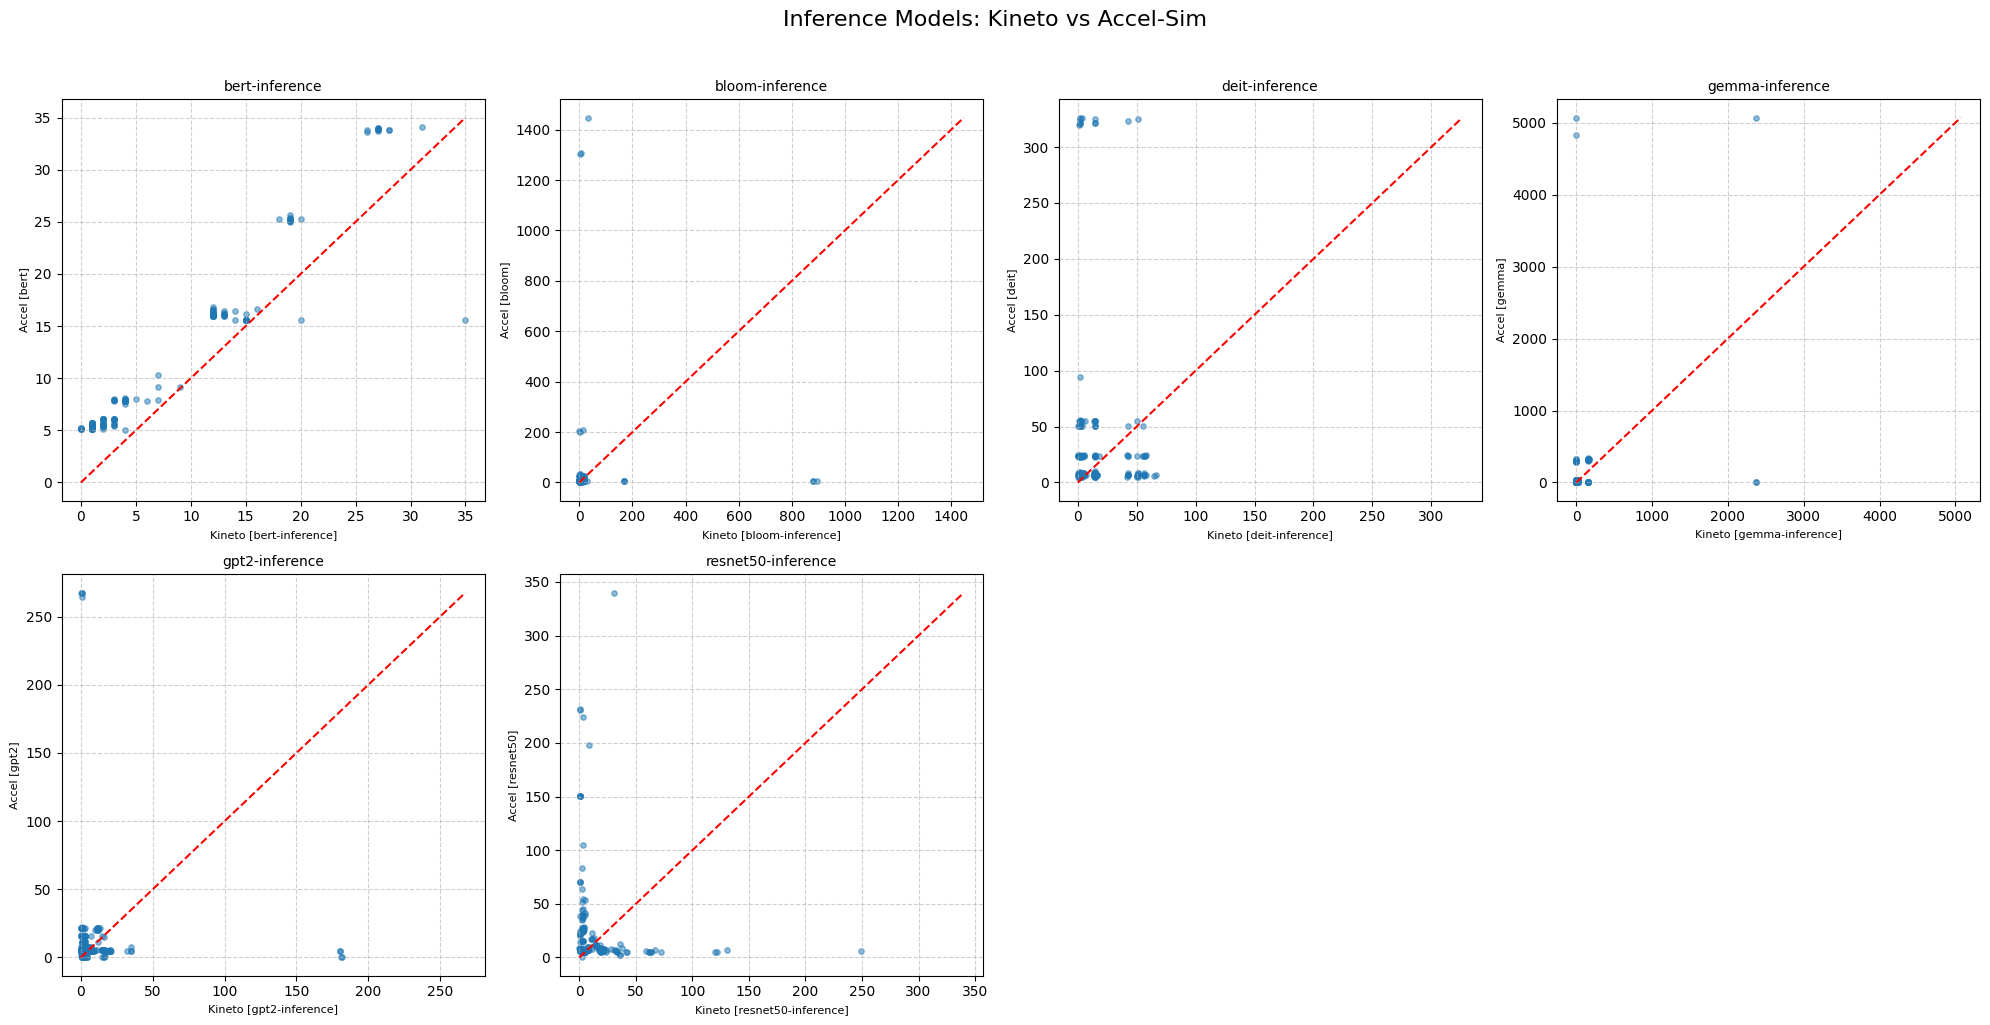

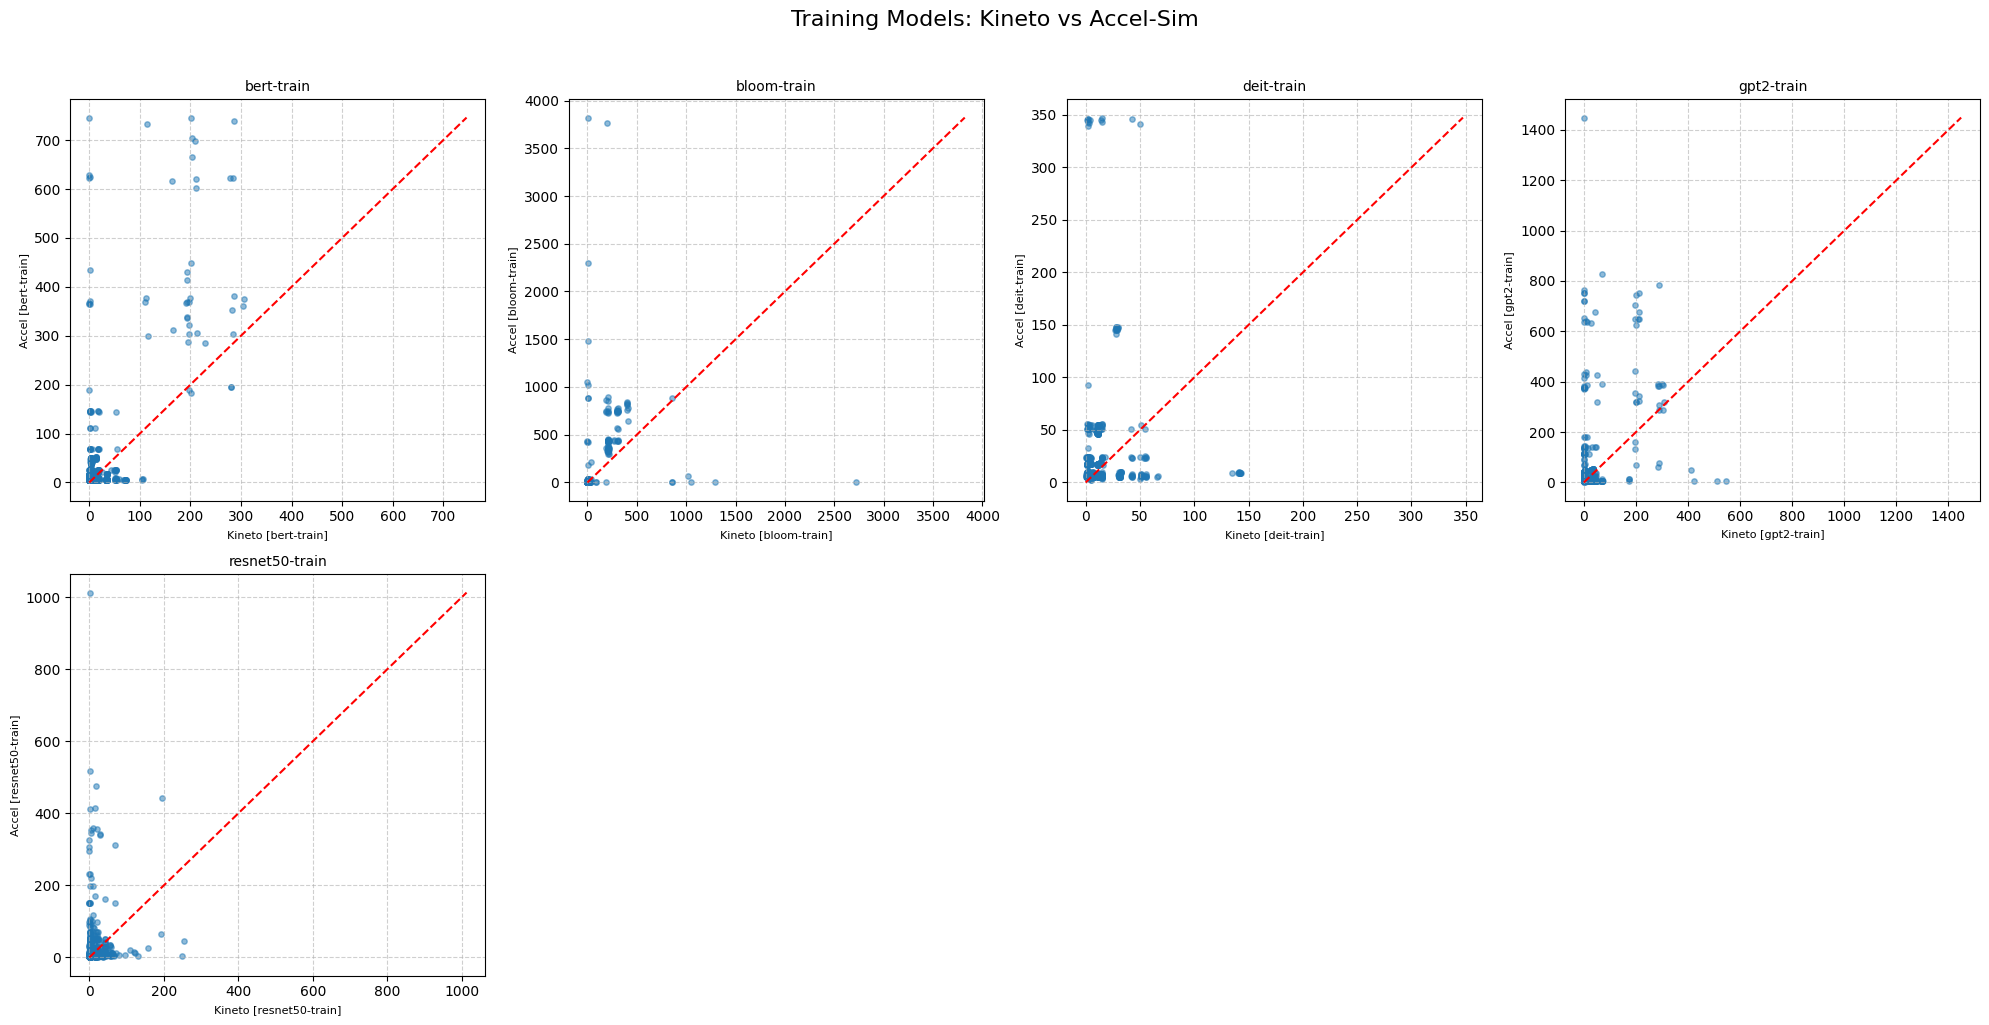

In [13]:
trace_root_dir = "/proj/threadtune-PG0/amir/kineto_traces/"
print(f"Searching for models in: {trace_root_dir}")

# Lists to hold the processed data objects
inference_data_list = []
train_data_list = []

model_paths = sorted(glob.glob(os.path.join(trace_root_dir, "*")))

for path in model_paths:
    if os.path.isdir(path):
        # 1. Extract Data
        result = get_model_data(path)
        
        if result:
            # 2. Sort into Inference vs Train based on folder name
            folder_name = os.path.basename(path.rstrip('/'))
            
            if "inference" in folder_name:
                inference_data_list.append(result)
            else:
                train_data_list.append(result)

print(f"\n{'='*60}")
print(f"Found {len(inference_data_list)} inference models and {len(train_data_list)} training models.")
print(f"{'='*60}\n")

# 3. Plot Grids
plot_grid(inference_data_list, grid_title="Inference Models: Kineto vs Accel-Sim")
plot_grid(train_data_list, grid_title="Training Models: Kineto vs Accel-Sim")

In [14]:
!pip install xlsxwriter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 KB 2.7 MB/s eta 0:00:0000:01


In [ ]:
import os
import glob
import polars as pl
import pandas as pd # Needed for the ExcelWriter engine
from hta.trace_analysis import TraceAnalysis

def get_raw_model_data(kineto_path):
    # 1. Determine Model Names
    model_dir_name = os.path.basename(kineto_path.rstrip('/'))
    
    if "inference" in model_dir_name:
        accel_model_name = model_dir_name.split('-')[0]
    else:
        accel_model_name = model_dir_name
    
    print(f"Processing: {model_dir_name}...")

    # 2. Load Kineto (Trace) Data
    try:
        if not os.path.exists(os.path.join(kineto_path, "device.0.json")):
            print(f"  -> Skipping: device.0.json not found.")
            return None

        analyzer = TraceAnalysis({0: "device.0.json"}, kineto_path)
        rank = 0
        trace_data = analyzer.t.get_trace(rank)
        symbol_table = analyzer.t.symbol_table.get_sym_table()
        
        # Create Kineto DataFrame
        trace_df = pl.concat(
             pl.from_pandas(trace_data[trace_data["stream"] != -1][["name", "dur"]])
             .select(pl.lit(rank).alias("rank"), pl.all())
             for rank, trace_data in analyzer.t.traces.items()
        ).join(
            pl.from_dict({"name": list(range(len(symbol_table))), "s_name": symbol_table}),
            on="name",
        ).filter(
            ~pl.col("s_name").str.starts_with("nccl") & 
            ~pl.col("s_name").is_in(["Stream Sync", "Memcpy DtoD (Device -> Device)", "Memcpy HtoD (Pageable -> Device)", "Memcpy DtoH (Device -> Pinned)"])
        ).select(
            pl.col("s_name").alias("Kineto_Kernel"),
            pl.col("dur").alias("Kineto_Time_us")
        )
        
    except Exception as e:
        print(f"  -> Error reading trace: {e}")
        return None

    # 3. Load Accel-Sim Data
    # Assuming accel_df_all is already loaded in your notebook
    accel_df = accel_df_all.filter(pl.col("model") == accel_model_name)
    
    if len(accel_df) == 0:
        print(f"  -> Warning: No Accel-Sim data found for {accel_model_name}")
        # Create an empty DF with correct columns so Excel doesn't break
        accel_df = pl.DataFrame({"Accel_Kernel": [], "Accel_Time_us": []})
    else:
        # Select relevant columns for Excel (Customize this list as needed)
        # Assuming your accel_df has 'kernel_name' and 'accel_time_us'
        accel_df = accel_df.select(
            pl.col("kernel").alias("Accel_Kernel"),
            pl.col("accel_time_us").alias("Accel_Time_us"),
            pl.col("model").alias("Accel_Model_Name")
        )

    return {
        "name": model_dir_name,
        "trace_df": trace_df,
        "accel_df": accel_df
    }

In [19]:
def save_side_by_side_excel(data_list, output_filename="Model_Comparison.xlsx"):
    print(f"\nWriting to {output_filename}...")
    
    # Use pandas ExcelWriter with xlsxwriter engine
    with pd.ExcelWriter(output_filename, engine='xlsxwriter') as writer:
        for item in data_list:
            sheet_name = item['name']
            
            # Excel sheet names max length is 31 chars
            if len(sheet_name) > 31:
                sheet_name = sheet_name[:31]
            
            # Convert Polars to Pandas for easy writing
            pdf_accel = item['accel_df'].to_pandas()
            pdf_trace = item['trace_df'].to_pandas()
            
            # --- Write Accel Data (Left Side) ---
            pdf_accel.to_excel(writer, sheet_name=sheet_name, startrow=0, startcol=0, index=False)
            
            # --- Write Kineto Data (Right Side) ---
            # Leave a gap. If Accel has 3 cols, we start at col 4 (index 4 = 5th column)
            gap = 2
            start_col_kineto = len(pdf_accel.columns) + gap
            
            pdf_trace.to_excel(writer, sheet_name=sheet_name, startrow=0, startcol=start_col_kineto, index=False)
            
            # Optional: Add Headers styling or Column sizing via workbook objects
            workbook = writer.book
            worksheet = writer.sheets[sheet_name]
            
            # Add a label in the gap
            header_format = workbook.add_format({'bold': True, 'font_color': 'red'})
            worksheet.write(0, start_col_kineto - 1, "||", header_format)

    print(f"Successfully saved {output_filename}")

In [20]:
trace_root_dir = "/proj/threadtune-PG0/amir/kineto_traces/"
model_paths = sorted(glob.glob(os.path.join(trace_root_dir, "*")))

inference_results = []
train_results = []

print(f"Scanning {len(model_paths)} directories...")

for path in model_paths:
    if os.path.isdir(path):
        result = get_raw_model_data(path)
        
        if result:
            folder_name = result['name']
            if "inference" in folder_name:
                inference_results.append(result)
            else:
                train_results.append(result)

# --- Save to Excel ---
if inference_results:
    save_side_by_side_excel(inference_results, "Inference_Comparison.xlsx")

if train_results:
    save_side_by_side_excel(train_results, "Train_Comparison.xlsx")

Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json time = 0.04 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425


Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json backend=json in 0.12 seconds; current PID:575224
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json in 0.15 seconds; current PID:575224
leaving parse_multiple_ranks duration=0.15 seconds
leaving parse_traces duration=0.15 seconds
There is only one iteration in the trace. The analysis result may not be accurate.


Scanning 11 directories...
Processing: bert-inference...
Processing: bert-train...


Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json time = 0.29 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json backend=json in 0.56 seconds; current PID:575224
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json in 0.62 seconds; current PID:575224
leaving parse_multiple_ranks duration=0.63 seconds
leaving parse_traces duration=0.63 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/bloom-inference/device.0.json time = 0.02 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/bl

Processing: bloom-inference...
Processing: bloom-train...


...

Processing: gpt2-train...


Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-train/device.0.json time = 0.23 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-train/device.0.json backend=json in 0.43 seconds; current PID:575224
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/gpt2-train/device.0.json in 0.48 seconds; current PID:575224
leaving parse_multiple_ranks duration=0.49 seconds
leaving parse_traces duration=0.49 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/resnet50-inference/device.0.json time = 0.01 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces

Processing: resnet50-inference...
Processing: resnet50-train...


Parsed /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json time = 0.24 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json backend=json in 0.42 seconds; current PID:575224
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json in 0.47 seconds; current PID:575224
leaving parse_multiple_ranks duration=0.47 seconds
leaving parse_traces duration=0.47 seconds
There is only one iteration in the trace. The analysis result may not be accurate.



Writing to Inference_Comparison.xlsx...
Successfully saved Inference_Comparison.xlsx

Writing to Train_Comparison.xlsx...
Successfully saved Train_Comparison.xlsx
